<a href="https://colab.research.google.com/github/PolyakovMA/chocolate-review/blob/main/Chocolate_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В датасете содержится информация о более чем 1700 шоколадках. В датасете представлена информация о темном шоколаде.

Задача, решаемая в данном ноутбуке - по характеристикам шоколадки научиться предсказывать ее рейтинг без округлений.

Никнейм участника соревнования на платформе kaggle: michigobbi

Устанавливаем дополнительные библиотеки:

In [1]:
!pip install catboost -q
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 10.9 MB/s eta 0:00:00


Импортируем необходимый функционал:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency


Задаем константы:

In [3]:
RANDOM_STATE = 42

Загружаем тренировочную и тестовую части датасета с github и смотри как выглядит датасет:

In [4]:
url = "https://raw.githubusercontent.com/PolyakovMA/chocolate-review/main/data/chocolate_train.csv"
url_test = "https://raw.githubusercontent.com/PolyakovMA/chocolate-review/main/data/chocolate_test_new.csv"

X_test = pd.read_csv(url_test)
X_train = pd.read_csv(url)

X_train.head()

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


Краткая информация и типах данных и пропущенных значениях представлена ниже. Пропущенные значения присутствуют в датасете.

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1255 non-null   object 
 1   Specific Bean Origin  1255 non-null   object 
 2   REF                   1255 non-null   int64  
 3   Review                1255 non-null   int64  
 4   Cocoa Percent         1255 non-null   object 
 5   Company Location      1255 non-null   object 
 6   Rating                1255 non-null   float64
 7   Bean Type             1254 non-null   object 
 8   Broad Bean Origin     1254 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 88.4+ KB


Ниже приведены статистические показатели по каждому признаку датасета:

In [ ]:
X_train.describe(include='all')

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
count,1255,1255,1255.000000,1255.000000,1255,1255,1255.000000,1254,1254
unique,376,762,NaN,NaN,40,58,NaN,38,84
top,Soma,Madagascar,NaN,NaN,70%,U.S.A.,NaN,,Venezuela
freq,35,39,NaN,NaN,461,521,NaN,628,144
mean,NaN,NaN,1045.152191,2012.382470,NaN,NaN,3.176494,NaN,NaN
std,NaN,NaN,551.284249,2.922499,NaN,NaN,0.478948,NaN,NaN
min,NaN,NaN,5.000000,2006.000000,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,593.000000,2010.000000,NaN,NaN,2.750000,NaN,NaN
50%,NaN,NaN,1077.000000,2013.000000,NaN,NaN,3.250000,NaN,NaN
75%,NaN,NaN,1514.000000,2015.000000,NaN,NaN,3.500000,NaN,NaN


Признаки, в которых имеются пропущенные значения и количество пропущенных значений указаны ниже:

In [ ]:
X_train.isna().sum()[X_train.isna().sum() > 0]

,0
Bean Type,1
Broad Bean Origin,1


Всего 2 строки во всем датасете имеют пропущенные значения:

In [ ]:
X_train.loc[   (X_train['Bean Type'].isna())   |
                (X_train['Broad Bean Origin'].isna())
                ]

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
697,Mast Brothers,Madagascar,999,2012,72%,U.S.A.,2.5,Trinitario,NaN
1058,Soma,"Three Amigos(Chuao, Wild Bolivia, D.R.)",676,2011,70%,Canada,4.0,NaN,"Ven, Bolivia, D.R."


Всего строк в датасете:

In [ ]:
X_train.shape[0]

1255

Удалим из датасета обе строки с пропущенными значениями:

In [5]:
X_train = X_train.dropna()
X_train.shape

(1253, 9)

Разделим целевую переменную и признаки:

In [6]:
y_train = X_train['Rating']
X_train = X_train.drop('Rating', axis=1)

Начнем анализировать признаки. Создадим датафрейм, содержащий только числовые признаки:

In [7]:
df_numerical = X_train.select_dtypes(include=['int64', 'float64'])
df_numerical.head()

,REF,Review
0,457,2009
1,508,2010
2,1554,2015
3,1125,2013
4,32,2006


Также создадим датафрейм, содержащий только категориальные признаки:

In [8]:
df_categorical = X_train.select_dtypes(include=['object'])
df_categorical.head()

,Company,Specific Bean Origin,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,72%,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",72%,Switzerland,,Venezuela
2,Dark Forest,Tanzania,70%,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,72%,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",75%,France,Criollo,Indonesia


При детальном рассмотрении категориальных признаков мы видим, что признак "Cocoa Percent" - числовой, а не категориальный:

In [ ]:
df_categorical["Cocoa Percent"].unique()

array(['72%', '70%', '75%', '80%', '77%', '68%', '72.5%', '74%', '58%',
       '65%', '82%', '60%', '66%', '64%', '88%', '76%', '81%', '61%',
       '73%', '91%', '67%', '78%', '100%', '85%', '69%', '83%', '62%',
       '71%', '53%', '55%', '90%', '63%', '46%', '86%', '73.5%', '99%',
       '84%', '56%', '50%', '87%'], dtype=object)

Поэтому перенесем признак "Cocoa Percent" из категориального датафрейма в числовой, предварительно обработав сам признак:

In [9]:
df_numerical["Cocoa Percent"] = df_categorical["Cocoa Percent"].str.rstrip('%').astype(float)
df_numerical.head()

,REF,Review,Cocoa Percent
0,457,2009,72.0
1,508,2010,72.0
2,1554,2015,70.0
3,1125,2013,72.0
4,32,2006,75.0


Аналогичную операцию проделаем с тестовым датафреймом:

In [10]:
X_test["Cocoa Percent"] = X_test["Cocoa Percent"].str.rstrip('%').astype(float)

Удалим "Cocoa Percent" из категориального датафрейма:

In [11]:
df_categorical = df_categorical.drop(columns=["Cocoa Percent"])
df_categorical.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,,Venezuela
2,Dark Forest,Tanzania,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia


Соединим целевую переменную с числовым датафремом для дальнейшего анализа:

In [12]:
numerical = pd.concat([df_numerical, y_train], axis=1)
numerical.head()

,REF,Review,Cocoa Percent,Rating
0,457,2009,72.0,3.25
1,508,2010,72.0,3.50
2,1554,2015,70.0,3.00
3,1125,2013,72.0,3.00
4,32,2006,75.0,3.50


Посмотрим на тепловую карту, на которой отражена корреляция числовых признаком с целевой переменной. Отметим для себя, что признаки "Review" и "REF" очень сильно коррелируют друг с другом (0,98), но на данном этапе мы сохраним оба этих признака.

<Axes: >

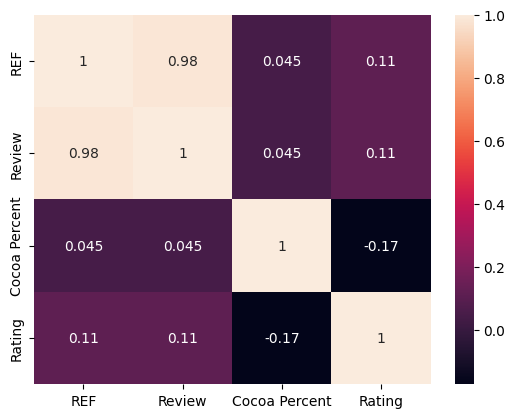

In [ ]:
sns.heatmap(numerical.corr(), annot=True)

Посмотрим на графики зависимости целевой переменной от числовых признаков.

Визуальных закономерностей\зависимостей не обнаружено.

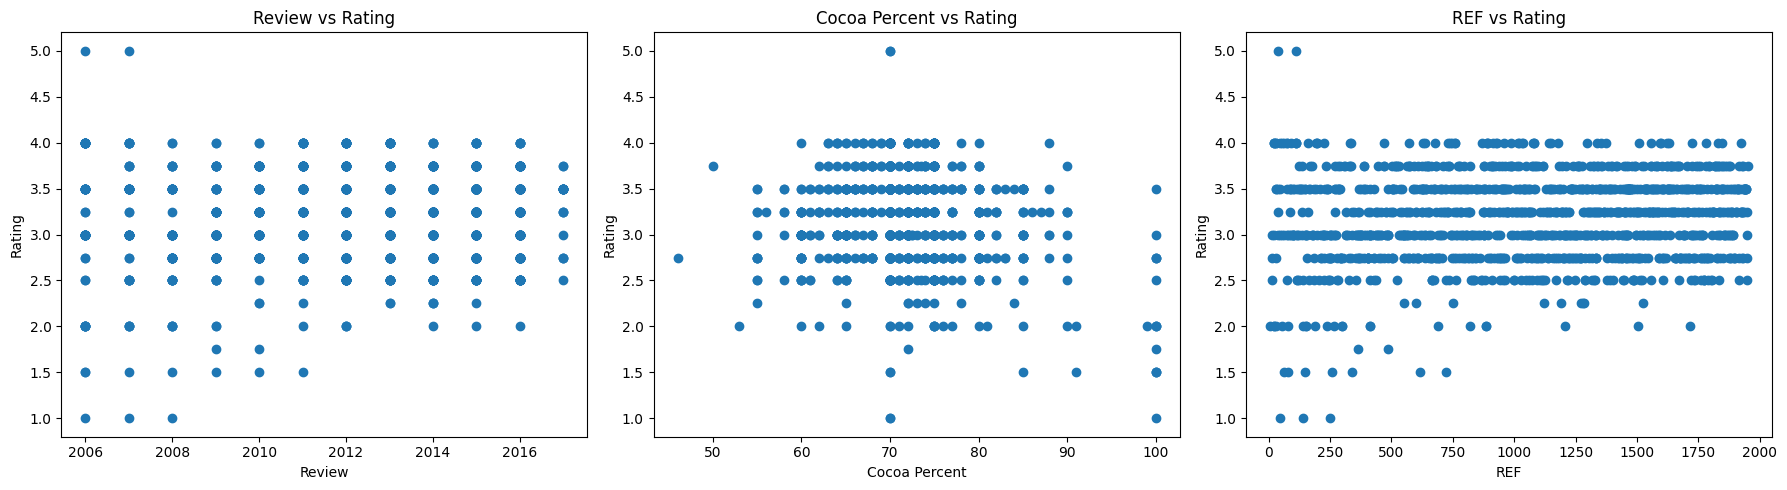

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Review', 'Cocoa Percent', 'REF']

for i, f in enumerate(features):
    axes[i].scatter(numerical[f], numerical['Rating'])
    axes[i].set_title(f'{f} vs Rating')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Rating')

plt.tight_layout()
plt.show()

Посмотрим на рапределение целевой переменной и числовых признаков. Хотя модель Catboost не требует нормальности распределения для целевой переменной или признаков, но для понимания корректности корреляции, отраженной на предыдущем шаге это допустимо. 'Cocoa Percent', 'Rating' приблизительно похожи на нормальное распределение, значит мы можем доверять данным корреляции между этими показателями.

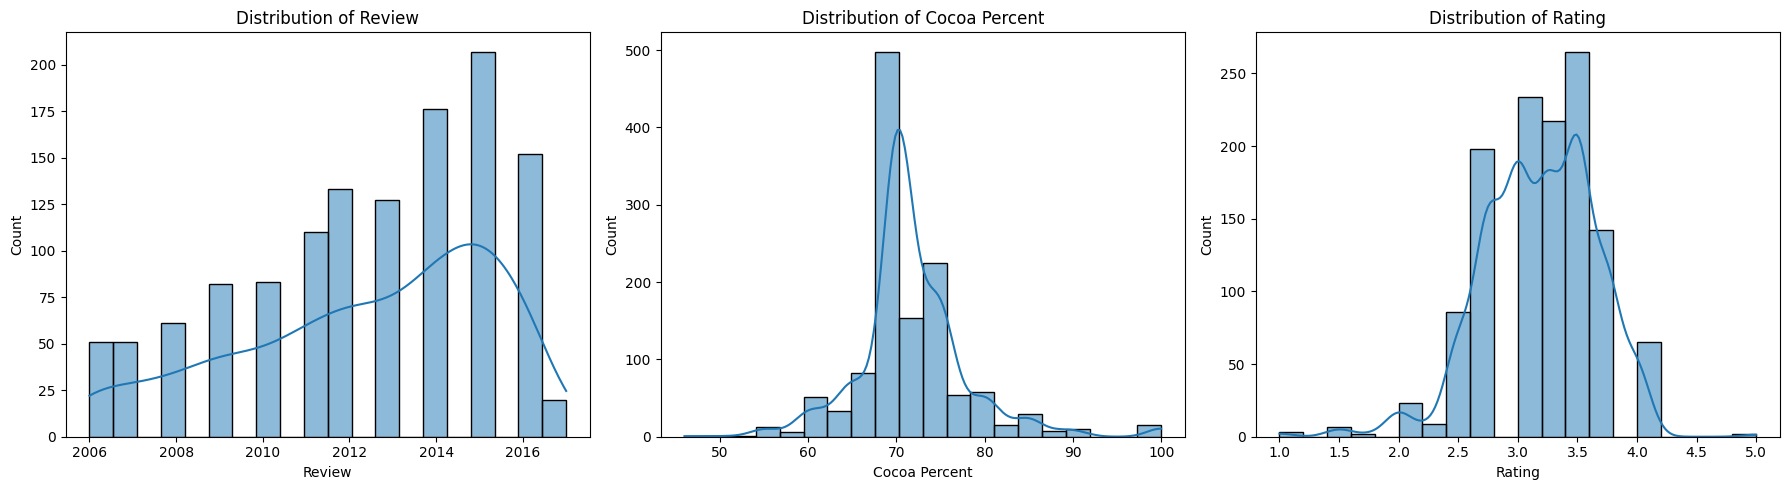

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Review', 'Cocoa Percent', 'Rating']

for i, f in enumerate(features):
    sns.histplot(numerical[f], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribution of {f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

Теперь внимательнее изучим датафрейм с категориальными переменными. Количество уникальных классов очень велико во ВСЕХ признаках, это означает, что нашему алгоритму будет тяжело искать взаимосвязи.

In [13]:
for i in df_categorical.columns:
    print(f'{i}:', df_categorical[i].nunique())


Company: 376
Specific Bean Origin: 761
Company Location: 58
Bean Type: 38
Broad Bean Origin: 83


Определим две вспомогательные функции, чтобы анализировать категориальные данные:

In [14]:
def analyze_feature(feature):

  df_count = df_categorical[feature].value_counts(normalize=True)
  print(df_count.to_string())

def select_other(feature):

  df_count = df_categorical[feature].value_counts(normalize=True)
  min_threshold = df_count.iloc[-1]

  other_mask = df_count[df_count == min_threshold]
  other = other_mask.sum()

  return other_mask, other

Для признака 'Company' очень много уникальных значений и каждая из них составляет менее 3% от датасета. Мы будем просматривать весь список целиком (to_string) т.к мы впоследствии встретим интересное значение категориальной переменной у "Bean Type":

In [15]:
analyze_feature('Company')

Company
Soma                                       0.027135
Bonnat                                     0.015962
A. Morin                                   0.015164
Fresco                                     0.013567
Valrhona                                   0.012769
Pralus                                     0.012769
Arete                                      0.012769
Hotel Chocolat (Coppeneur)                 0.011971
Rogue                                      0.011173
Artisan du Chocolat                        0.011173
Zotter                                     0.010375
Domori                                     0.010375
Szanto Tibor                               0.010375
Guittard                                   0.010375
Coppeneur                                  0.009577
Dick Taylor                                0.008779
Scharffen Berger                           0.008779
Mast Brothers                              0.008779
Duffy's                                    0.007981
Smoo

Мы опредили, что доля самых редко встречающихся компаний составляет приблизительно 10% от величины датасета. В дальнейшем мы можем попробовать сгруппировать эти компании под одним наименованием (например Other)

In [16]:
comp_mask, comp_per = select_other('Company')
comp_per

np.float64(0.10853950518754989)

Проделаем аналогичные действия с признаком 'Specific Bean Origin':

In [17]:
analyze_feature('Specific Bean Origin')

Specific Bean Origin
Madagascar                                       0.030327
Peru                                             0.027135
Ecuador                                          0.024741
Dominican Republic                               0.023144
Chuao                                            0.011173
Sambirano                                        0.010375
Venezuela                                        0.010375
Ocumare                                          0.009577
Ghana                                            0.007981
Papua New Guinea                                 0.007183
Porcelana                                        0.007183
Brazil                                           0.006385
Alto Beni                                        0.006385
Tanzania                                         0.006385
Bolivia                                          0.006385
Grenada                                          0.006385
Belize                                           0.

Получается, что доля редко встречающихся значений для этого признака составляет почти 50%. На данныый момент ничего не будем с этим делать, но имеем ввиду, что такой признак вероятно малоинформативен.

In [18]:
sp_bean_mask, sp_bean_per = select_other('Specific Bean Origin')
sp_bean_per

np.float64(0.49481245011971264)

Смотрим признак 'Company Location':

In [19]:
analyze_feature('Company Location')

Company Location
U.S.A.               0.415004
France               0.092578
Canada               0.070231
U.K.                 0.059058
Ecuador              0.033520
Italy                0.032721
Australia            0.025539
Switzerland          0.019952
Belgium              0.019952
Austria              0.017558
Germany              0.017558
Spain                0.012769
Venezuela            0.011971
Hungary              0.011971
Colombia             0.011173
New Zealand          0.010375
Brazil               0.010375
Peru                 0.010375
Madagascar           0.009577
Japan                0.008779
Vietnam              0.007183
Denmark              0.006385
Poland               0.005587
Scotland             0.005587
Guatemala            0.004789
Honduras             0.004789
Argentina            0.004789
Costa Rica           0.004789
Domincan Republic    0.003990
Sweden               0.003990
Israel               0.003990
Lithuania            0.002394
Fiji                 0.

Для этого признака можно будет пробовать объединять в "прочие" больше строк (не только те, у которых самое минимальное число почвлений в датасете):

In [20]:
comp_loc_mask, comp_loc_per = select_other('Company Location')
comp_loc_per

np.float64(0.007980845969672785)

Смотрим признак 'Bean Type' и обращаем внимание, что 50% датасета имеют "пустое" значение. Также стоит отметить что почти все уникальные значения так или иначе похожи друг на друга. Возможно этот признак будет необходимо унифицировать (подойдет сплит по пробелу, запятой или скобке):

In [21]:
analyze_feature('Bean Type')

Bean Type
                            0.501197
Trinitario                  0.226656
Criollo                     0.083001
Forastero                   0.042298
Forastero (Nacional)        0.027135
Criollo, Trinitario         0.025539
Forastero (Arriba)          0.025539
Blend                       0.022346
Criollo (Porcelana)         0.007183
Forastero (Parazinho)       0.006385
Forastero (Arriba) ASS      0.004789
Nacional (Arriba)           0.002394
Trinitario, Criollo         0.002394
Criollo (Amarru)            0.001596
Forastero (Catongo)         0.001596
Criollo, Forastero          0.001596
Trinitario, Forastero       0.001596
Amazon mix                  0.000798
Matina                      0.000798
Trinitario, TCGA            0.000798
Trinitario (Amelonado)      0.000798
Forastero(Arriba, CCN)      0.000798
Amazon, ICS                 0.000798
Criollo (Ocumare 77)        0.000798
Criollo (Ocumare)           0.000798
Nacional                    0.000798
Criollo, +                  

Выдеять "прочие" скорее всего будет не нужно, если мы решим унифицировать значения.

In [22]:
bean_mask, bean_per = select_other('Bean Type')
bean_per

np.float64(0.01675977653631285)

Заменим пустые строки на 'Unknown':

In [23]:
df_categorical['Bean Type'] = df_categorical['Bean Type'].replace('\xa0', 'Unknown')
df_categorical['Bean Type'].unique()

array(['Trinitario', 'Unknown', 'Criollo', 'Criollo, Trinitario',
       'Forastero (Arriba)', 'Amazon mix', 'Forastero (Arriba) ASS',
       'Forastero', 'Trinitario, Forastero', 'Forastero (Nacional)',
       'Criollo (Porcelana)', 'Criollo (Amarru)',
       'Forastero(Arriba, CCN)', 'Trinitario (Amelonado)', 'Blend',
       'Forastero (Parazinho)', 'Matina', 'Nacional (Arriba)',
       'Trinitario, TCGA', 'Criollo, Forastero', 'Criollo (Ocumare 77)',
       'Amazon, ICS', 'Nacional', 'Criollo (Ocumare)', 'Criollo, +',
       'Forastero (Catongo)', 'Amazon', 'Criollo (Wild)',
       'Trinitario, Criollo', 'EET', 'Trinitario (85% Criollo)',
       'Criollo (Ocumare 61)', 'Forastero, Trinitario',
       'Blend-Forastero,Criollo', 'Criollo (Ocumare 67)',
       'Forastero (Amelonado)', 'Trinitario, Nacional',
       'Forastero (Arriba) ASSS'], dtype=object)

Аналогично для тестового датафрейма:

In [24]:
X_test['Bean Type'] = X_test['Bean Type'].replace('\xa0', 'Unknown')

В признаке 'Broad Bean Origin' тоже есть пустые значения:

In [25]:
analyze_feature('Broad Bean Origin')

Broad Bean Origin
Venezuela                       0.114924
Ecuador                         0.113328
Peru                            0.097366
Dominican Republic              0.083001
Madagascar                      0.082203
                                0.043895
Brazil                          0.034318
Bolivia                         0.033520
Nicaragua                       0.033520
Belize                          0.023943
Vietnam                         0.023144
Tanzania                        0.021548
Colombia                        0.020750
Costa Rica                      0.020750
Ghana                           0.019154
Trinidad                        0.018356
Papua New Guinea                0.018356
Mexico                          0.014366
Guatemala                       0.012769
Domincan Republic               0.012769
Jamaica                         0.011173
Hawaii                          0.011173
Grenada                         0.009577
Honduras                        0.00877

Доля самых редких значений составляет:

In [26]:
broad_bean_mask, broad_bean_per = select_other('Broad Bean Origin')
broad_bean_per

np.float64(0.02314445331205108)

Посмотрим на взаимосвязь между категориальными признаками (аналог корелляции, но для категориальных данных) V-меру Крамера. Для этого создадим вспомогательную функцию, которая будет возвращать матрицу, заполненную V мерой для каждой пары категориальных признаков:

In [ ]:
# V мера между парой категориальных признаков
def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    r, k = cm.shape
    v = np.sqrt((chi2 / n) / (min(k-1, r-1)))
    return v


In [ ]:
# На основании V мер, рассчитанных для каждой пары категориальных признаков, заполняется матрица
def cramers_v_matrix(df):
    cols = df_categorical.columns
    n = len(cols)
    v_mat = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in cols:
        for j in cols:
            v_mat.loc[i, j] = cramers_v(df[i], df[j])

    return v_mat

Тепловая карта показывает нам, что категориальные признаки сильно зависимы друг от друга:

'Specific Bean Origin" с 'Broad Bean Origin' - логично

'Company' c 'Company Location'  - логично

'Bean Type' со 'Specific Bean Origin' - здесь на уровне логики мы пока не можем подвердить или опровергнут эту зависимость, особенно с учетом того, что 50% данных в 'Bean Type' были пустые

Text(0.5, 1.0, "Cramer's V Heatmap")

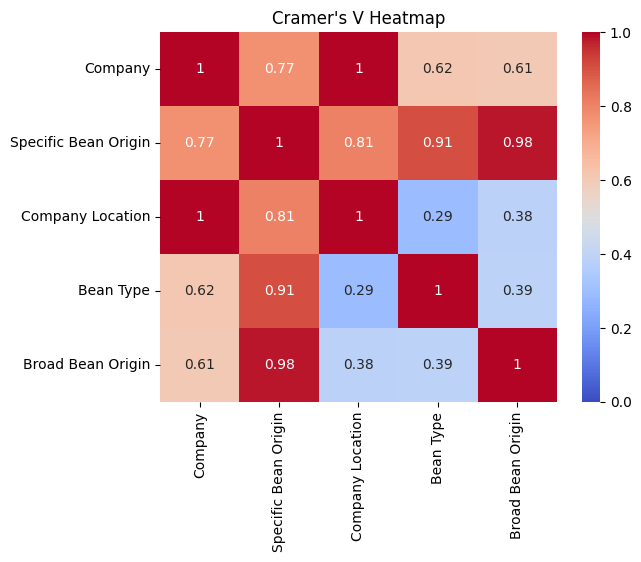

In [ ]:
v_matrix = cramers_v_matrix(df_categorical)

sns.heatmap(v_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramer's V Heatmap")

Соединим числовой и категориальный датафреймы т.к мы проводили над ними операции:

In [27]:
X_train = pd.concat([df_categorical, df_numerical], axis=1)
X_train.head()


,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,REF,Review,Cocoa Percent
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela,457,2009,72.0
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,Venezuela,508,2010,72.0
2,Dark Forest,Tanzania,U.S.A.,Unknown,Tanzania,1554,2015,70.0
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic,1125,2013,72.0
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia,32,2006,75.0


Упорядочим признаки в тестовом датафрейме (чтобы признаки в трейне и тесте шли в одинаковом порядке):

In [28]:
X_test = X_test[X_train.columns]
X_test.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,REF,Review,Cocoa Percent
0,Ohiyo,"San Juan Estate, Gran Couva",U.S.A.,Trinitario,Trinidad,1594,2015,70.0
1,Blanxart,Organic Dark,Spain,Unknown,,322,2009,72.0
2,Brazen,Maya Mountain,U.S.A.,Trinitario,Belize,1518,2015,80.0
3,Patric,Madagascar,U.S.A.,Trinitario,Madagascar,439,2009,67.0
4,Potomac,"Upala, Batch 12",U.S.A.,Matina,Costa Rica,607,2010,82.0


Разделим трейн на трейн и валидацию:

In [ ]:
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

Создадим бейзлайн модель:

In [ ]:
model = CatBoostRegressor(cat_features=list(df_categorical.columns),
                          random_seed=42)

In [ ]:
model.fit(X_train_1, y_train_1, verbose=0)

In [ ]:
pred = model.predict(X_val_1)

Качество модели:

In [ ]:
r2_score(y_val_1, pred)

0.1288896946485968

Посмотрим на важность признаков, составленную моделью:

In [ ]:
importances = model.get_feature_importance(prettified=True)
importances

,Feature Id,Importances
0,Company,19.850068
1,Broad Bean Origin,15.546750
2,Company Location,15.517011
3,REF,14.521953
4,Cocoa Percent,14.079210
5,Bean Type,11.165937
6,Specific Bean Origin,5.018680
7,Review,4.300391


Теперь обучим модель на всей выборке (с учетом валидационной части):

In [ ]:
model.fit(X_train, y_train, verbose=0)
pred = model.predict(X_test)

result_df = pd.DataFrame({'id': X_test.index, 'Rating': pred})
result_df.head()

,id,Rating
0,0,3.109363
1,1,2.967099
2,2,3.048766
3,3,3.799170
4,4,2.932666


Данный результат при загрузке на kaggle дает R2 = 0.17733

In [ ]:
result_df.to_csv("catboost_submission_0.csv", index=False)

Применим "ленивый подход" и проверим, можно ли пройти необходимый порог R2, не применяя никаких преобразований и отборов. Для этого определим функцию подбора гиперпараметров CatBoost через Optuna с учетом кросс-валидации:

In [29]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
        'cat_features': list(df_categorical.columns),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, verbose=0)

        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores)

In [ ]:
study = optuna.create_study(direction='maximize')  # потому что R² — чем выше, тем лучше
study.optimize(objective,
               n_trials=30,
               show_progress_bar = True)

[I 2025-11-16 13:31:53,172] A new study created in memory with name: no-name-4c4514d7-e451-49b1-ad65-a24ce182d334


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-16 13:32:06,854] Trial 0 finished with value: 0.11397950273450122 and parameters: {'iterations': 600, 'depth': 6, 'learning_rate': 0.2747056245107214, 'l2_leaf_reg': 2.354806415997545, 'bagging_temperature': 0.4777131210593082, 'random_strength': 0.4361553344863105}. Best is trial 0 with value: 0.11397950273450122.
[I 2025-11-16 13:32:16,324] Trial 1 finished with value: 0.16142587862045063 and parameters: {'iterations': 788, 'depth': 4, 'learning_rate': 0.12773300462730647, 'l2_leaf_reg': 7.620897849981049, 'bagging_temperature': 0.21834879989616074, 'random_strength': 0.9141255722041108}. Best is trial 1 with value: 0.16142587862045063.
[I 2025-11-16 13:32:39,311] Trial 2 finished with value: 0.17110885709056908 and parameters: {'iterations': 222, 'depth': 10, 'learning_rate': 0.026959833374796606, 'l2_leaf_reg': 9.560578174315745, 'bagging_temperature': 0.5258388172215689, 'random_strength': 0.46467740449291717}. Best is trial 2 with value: 0.17110885709056908.
[I 2025-11

In [ ]:
print("Лучшие параметры:", study.best_params)
print("Лучший AUC:", study.best_value)

Лучшие параметры: {'iterations': 1393, 'depth': 5, 'learning_rate': 0.010679293579594774, 'l2_leaf_reg': 6.676539210840905, 'bagging_temperature': 0.8895713362588883, 'random_strength': 0.7906226331760384}
Лучший AUC: 0.20376341761538544


In [ ]:
base_model = CatBoostRegressor(**study.best_params,
                                cat_features=list(df_categorical.columns),
                                loss_function='RMSE',
                                random_seed=42,
                                verbose=0
                                )

base_model.fit(X_train, y_train)

In [ ]:
pred = base_model.predict(X_test)

Эта модель при двух разных запусках показала на kaggle результаты 0.20201 и 0.19755:

In [ ]:
result_df = pd.DataFrame({'id': X_test.index, 'Rating': pred})
result_df.to_csv("catboost_submission_cv_1.csv", index=False)

In [ ]:
base_model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,Company,25.079399
1,Cocoa Percent,22.088366
2,REF,12.941044
3,Bean Type,10.140764
4,Company Location,9.166120
5,Broad Bean Origin,7.873821
6,Review,6.762160
7,Specific Bean Origin,5.948326


Попробуем удалить наименее важные признаки. Сначала создадим промежуточную копию датафремов, от которых будет отталкиваться:

In [31]:
train_df = X_train.copy()
test_df = X_test.copy()

Сначала попробуем удалить 'Specific Bean Origin':

In [ ]:
X_train_2 = train_df.drop(columns=['Specific Bean Origin'])
X_test_2 = test_df.drop(columns=['Specific Bean Origin'])

Напишем вспомогательную функцию для расчета R2 с учетом кросс-валидации:

In [ ]:
def test_this_sht(x_sht, y_sht, best_params, cat_features):

  kf = KFold(n_splits=5, shuffle=True, random_state=42)
  scores = []

  for train_idx, val_idx in kf.split(x_sht):

    X_tr, X_val = x_sht.iloc[train_idx], x_sht.iloc[val_idx]
    y_tr, y_val = y_sht.iloc[train_idx], y_sht.iloc[val_idx]

    model = CatBoostRegressor(**best_params,
                                cat_features=cat_features,
                                loss_function='RMSE',
                                random_seed=42,
                                verbose=0
                                )

    model.fit(X_tr, y_tr, verbose=0)
    pred = model.predict(X_val)
    scores.append(r2_score(y_val, pred))

  return np.mean(scores)


Параметры на данный момент будет брать из результатов, которые выдала Optuna:

In [ ]:
best_params = study.best_params
best_params

{'iterations': 1393,
 'depth': 5,
 'learning_rate': 0.010679293579594774,
 'l2_leaf_reg': 6.676539210840905,
 'bagging_temperature': 0.8895713362588883,
 'random_strength': 0.7906226331760384}

Определяем список категориальных переменных:

In [ ]:
cat_features = list(X_train_2.select_dtypes('object').columns)
cat_features

['Company', 'Company Location', 'Bean Type', 'Broad Bean Origin']

Результат получился чуть хуже (хотя в идеале надо заново подбирать параметры через Optuna, что мы и сделаем в конце):

In [ ]:
test_this_sht(X_train_2, y_train, best_params, cat_features)

np.float64(0.1931457893891006)

Нижеуказанное решение дает на kaggle результат 0.19470:

In [ ]:
model2 = CatBoostRegressor(**best_params,
                            cat_features=cat_features,
                            loss_function='RMSE',
                            random_seed=42,
                            verbose=0
                                )

model2.fit(X_train_2, y_train, verbose=0)
pred = model2.predict(X_test_2)

result_df = pd.DataFrame({'id': X_test_2.index, 'Rating': pred})
result_df.to_csv("catboost_submission_cv_2.csv", index=False)

Попробуем удалить признак "Review:

In [ ]:
X_train_2 = train_df.drop(columns=['Review'])
X_test_2 = test_df.drop(columns=['Review'])

In [ ]:
cat_features = list(X_train_2.select_dtypes('object').columns)
cat_features

['Company',
 'Specific Bean Origin',
 'Company Location',
 'Bean Type',
 'Broad Bean Origin']

Результат лучше, чем при удалении 'Specific Bean Origin':

In [ ]:
test_this_sht(X_train_2, y_train, best_params, cat_features)

np.float64(0.19676751008047094)

Если удалить 2 признака, R2 превысит необходимый порог:

In [ ]:
X_train_2 = train_df.drop(columns=['Review', 'Broad Bean Origin'])
X_test_2 = test_df.drop(columns=['Review', 'Broad Bean Origin'])

In [ ]:
cat_features = list(X_train_2.select_dtypes('object').columns)
cat_features

['Company', 'Specific Bean Origin', 'Company Location', 'Bean Type']

In [ ]:
test_this_sht(X_train_2, y_train, best_params, cat_features)

np.float64(0.20087979449935806)

Результат на kaggle 0.20133:

In [ ]:
model3 = CatBoostRegressor(**best_params,
                            cat_features=cat_features,
                            loss_function='RMSE',
                            random_seed=42,
                            verbose=0
                                )

model3.fit(X_train_2, y_train, verbose=0)
pred = model3.predict(X_test_2)

result_df = pd.DataFrame({'id': X_test_2.index, 'Rating': pred})
result_df.to_csv("catboost_submission_cv_3.csv", index=False)

Если удалить только 'Broad Bean Origin', то результат будет еще выше:

In [ ]:
X_train_2 = train_df.drop(columns=['Broad Bean Origin'])
X_test_2 = test_df.drop(columns=['Broad Bean Origin'])

In [ ]:
cat_features = list(X_train_2.select_dtypes('object').columns)
cat_features

['Company', 'Specific Bean Origin', 'Company Location', 'Bean Type']

In [ ]:
test_this_sht(X_train_2, y_train, best_params, cat_features)

np.float64(0.20297732511839578)

In [ ]:
model4 = CatBoostRegressor(**best_params,
                            cat_features=cat_features,
                            loss_function='RMSE',
                            random_seed=42,
                            verbose=0
                                )

model4.fit(X_train_2, y_train, verbose=0)
pred = model4.predict(X_test_2)

result_df = pd.DataFrame({'id': X_test_2.index, 'Rating': pred})
result_df.to_csv("catboost_submission_cv_4.csv", index=False)

Теперь попробуем изменить уже имеющиеся признаки, работать будем с признаком 'Bean Type'.

In [32]:
X_train_2 = train_df.drop(columns=['Broad Bean Origin'])
X_test_2 = test_df.drop(columns=['Broad Bean Origin'])

In [33]:
X_train_2.head()

,Company,Specific Bean Origin,Company Location,Bean Type,REF,Review,Cocoa Percent
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,457,2009,72.0
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,508,2010,72.0
2,Dark Forest,Tanzania,U.S.A.,Unknown,1554,2015,70.0
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,1125,2013,72.0
4,Pralus,"Java, Indonesie",France,Criollo,32,2006,75.0


Ранее мы уже отмечали, что многие значения в нем одинаковые и отличаются незначительно (например в скобках дается какое-либо уточнение):

In [ ]:
X_train_2['Bean Type'].value_counts()

,count
Bean Type,
Unknown,628
Trinitario,284
Criollo,104
Forastero,53
Forastero (Nacional),34
"Criollo, Trinitario",32
Forastero (Arriba),32
Blend,28
Criollo (Porcelana),9


Разделим признак 'Bean Type' на основную информацию и дополнительную:

In [34]:
X_train_2['Bean Type'] = X_train_2['Bean Type'].str.split(r'[ ,]+').str[0]
X_train_2['Bean Type_additional'] = X_train_2['Bean Type'].str.split(r'[ ,]+').str[1]

X_train_2['Bean Type_additional'] = X_train_2['Bean Type_additional'].replace(np.nan, 'Unknown')
X_train_2.head()

,Company,Specific Bean Origin,Company Location,Bean Type,REF,Review,Cocoa Percent,Bean Type_additional
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,457,2009,72.0,Unknown
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,508,2010,72.0,Unknown
2,Dark Forest,Tanzania,U.S.A.,Unknown,1554,2015,70.0,Unknown
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,1125,2013,72.0,Unknown
4,Pralus,"Java, Indonesie",France,Criollo,32,2006,75.0,Unknown


Тоже самое для теста:

In [35]:
X_test_2['Bean Type'] = X_test_2['Bean Type'].str.split(r'[ ,]+').str[0]
X_test_2['Bean Type_additional'] = X_test_2['Bean Type'].str.split(r'[ ,]+').str[1]

X_test_2['Bean Type_additional'] = X_test_2['Bean Type_additional'].replace(np.nan, 'Unknown')
X_test_2.head()

,Company,Specific Bean Origin,Company Location,Bean Type,REF,Review,Cocoa Percent,Bean Type_additional
0,Ohiyo,"San Juan Estate, Gran Couva",U.S.A.,Trinitario,1594,2015,70.0,Unknown
1,Blanxart,Organic Dark,Spain,Unknown,322,2009,72.0,Unknown
2,Brazen,Maya Mountain,U.S.A.,Trinitario,1518,2015,80.0,Unknown
3,Patric,Madagascar,U.S.A.,Trinitario,439,2009,67.0,Unknown
4,Potomac,"Upala, Batch 12",U.S.A.,Matina,607,2010,82.0,Unknown


In [36]:
cat_features = list(X_train_2.select_dtypes('object').columns)
cat_features

['Company',
 'Specific Bean Origin',
 'Company Location',
 'Bean Type',
 'Bean Type_additional']

Попробуем снова использовать Optuna:

In [37]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
        'cat_features': cat_features,
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_2):
        X_tr, X_val = X_train_2.iloc[train_idx], X_train_2.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, verbose=0)

        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores)

In [38]:
study = optuna.create_study(direction='maximize')  # потому что R² — чем выше, тем лучше
study.optimize(objective,
               n_trials=30,
               show_progress_bar = True)

[I 2025-11-17 06:23:05,346] A new study created in memory with name: no-name-fe1eee32-233a-4874-8a91-09a5aa1587c2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-17 06:23:14,085] Trial 0 finished with value: 0.14853591894558582 and parameters: {'iterations': 634, 'depth': 6, 'learning_rate': 0.18162405393507125, 'l2_leaf_reg': 5.04189711634149, 'bagging_temperature': 0.31087622741586307, 'random_strength': 0.7696842106045383}. Best is trial 0 with value: 0.14853591894558582.
[I 2025-11-17 06:24:28,953] Trial 1 finished with value: 0.11912326370612585 and parameters: {'iterations': 1247, 'depth': 9, 'learning_rate': 0.14956986104806716, 'l2_leaf_reg': 7.716334352632346, 'bagging_temperature': 0.8678654191784558, 'random_strength': 1.683546519549731}. Best is trial 0 with value: 0.14853591894558582.
[I 2025-11-17 06:25:57,148] Trial 2 finished with value: 0.08375624361949394 and parameters: {'iterations': 1032, 'depth': 10, 'learning_rate': 0.29536797622669997, 'l2_leaf_reg': 5.898854576446121, 'bagging_temperature': 0.9372898976206203, 'random_strength': 1.975362033759537}. Best is trial 0 with value: 0.14853591894558582.
[I 2025-11-1

In [39]:
print("Лучшие параметры:", study.best_params)
print("Лучший AUC:", study.best_value)

Лучшие параметры: {'iterations': 481, 'depth': 5, 'learning_rate': 0.03462696520346911, 'l2_leaf_reg': 6.355380230971081, 'bagging_temperature': 0.9196614631045325, 'random_strength': 1.076926291060294}
Лучший AUC: 0.198334427666563


In [40]:
model_2 = CatBoostRegressor(**study.best_params,
                                cat_features=cat_features,
                                loss_function='RMSE',
                                random_seed=42,
                                verbose=0
                                )

model_2.fit(X_train_2, y_train)
pred = model_2.predict(X_test_2)

Данное решение дает результат 0.20569:

In [41]:
result_df = pd.DataFrame({'id': X_test_2.index, 'Rating': pred})
result_df.to_csv("catboost_submission_cv_5.csv", index=False)

In [ ]:
best_params

{'iterations': 1393,
 'depth': 5,
 'learning_rate': 0.010679293579594774,
 'l2_leaf_reg': 6.676539210840905,
 'bagging_temperature': 0.8895713362588883,
 'random_strength': 0.7906226331760384}

In [ ]:
import json

with open("best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)